In [1]:
import pandas as pd
from matplotlib import pyplot as plt

from pathlib import Path

from xaikd import constants

from glob import glob

import matplotlib as mpl

import numpy as np

from datetime import datetime

In [2]:
ARTIFACT_DIR = Path("../../artifacts/2025-03-s52-revising-distillation/experiments/perf-curve/run1")
ARTIFACT_DIR

PosixPath('../../artifacts/2025-03-s52-revising-distillation/experiments/perf-curve/run1')

In [21]:
def load_data(model, layer, dataset_name, basis_name, verbose=False, data_size=1.0, ref_col="ref_auroc", stat_col="test_auroc"):
    path = ARTIFACT_DIR / model / dataset_name / f"data-size{data_size}" / layer / basis_name / "stats.csv"
    if verbose:
        print(f"path: {path}")

    files = sorted(list(glob(f"{path}")))
        
    
    if verbose:
        print(f"we have {len(files)} files")
    arr_dfs = [pd.read_csv(f) for f in files]
    
    df = pd.concat(arr_dfs)

    assert (df.arch.values == model).all()
    assert len(df.basis_name.unique()) == 1
    assert len(df.layer.unique()) == 1

    # return df
    
    df = df.groupby(["k"]).agg({
        ref_col: ["mean", "sem", "count"],
        stat_col: ["mean", "sem", "count"],
        "d": ["mean"]
    }).reset_index()
    
    return df
    
load_data("celeba-resnet18-scratch", "layer3", "celeba-attr*", "pca", verbose=True)

path: ../../artifacts/2025-03-s52-revising-distillation/experiments/perf-curve/run1/celeba-resnet18-scratch/celeba-attr*/data-size1.0/layer3/pca/stats.csv
we have 39 files


k ref_auroc                 test_auroc                      d
             mean       sem count       mean       sem count   mean
0     1  0.933756  0.010333    39   0.562182  0.009895    39  256.0
1     7  0.933756  0.010333    39   0.667975  0.019467    39  256.0
2    14  0.933756  0.010333    39   0.814027  0.018945    39  256.0
3    21  0.933756  0.010333    39   0.882889  0.014477    39  256.0
4    27  0.933756  0.010333    39   0.908123  0.012822    39  256.0
5    34  0.933756  0.010333    39   0.918605  0.011940    39  256.0
6    41  0.933756  0.010333    39   0.925015  0.011268    39  256.0
7    47  0.933756  0.010333    39   0.928906  0.010852    39  256.0
8    54  0.933756  0.010333    39   0.931289  0.010583    39  256.0
9    61  0.933756  0.010333    39   0.932484  0.010444    39  256.0
10   67  0.933756  0.010333    39   0.932930  0.010407    39  256.0
11   74  0.933756  0.010333    39   0.933489  0.010408    39  256.0
12   81  0.933756  0.010333    39   0.933700  0.010379    39  256.0
13   87  0.933756  0.010333    39   0.933843  0.010386    39  256.0
14   94  0.933756  0.010333    39   0.933945  0.010371    39  256.0
15  101  0.933756  0.010333    39   0.933910  0.010360    39  256.0
16  107  0.933756  0.010333    39   0.934031  0.010348    39  256.0
17  114  0.933756  0.010333    39   0.934059  0.010327    39  256.0
18  121  0.933756  0.010333    39   0.934146  0.010343    39  256.0
19  128  0.933756  0.010333    39   0.933937  0.010321    39  256.0
20  256  0.933756  0.010333    39   0.933749  0.010333    39  256.0

# Some-vs-Others

## CIFAR100-*-vs-others

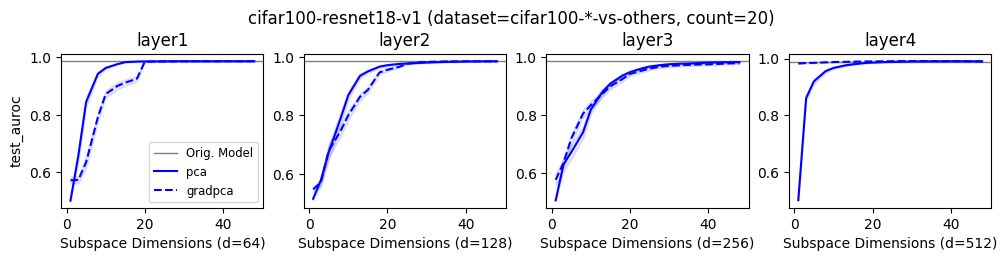

In [4]:
def alias(name):
    return name.replace("with-weight", "")
    # return {
    #     "prca-ablation-a-c": "prcaposdefv2",
    # }.get(name, name)
    
def viz(
    dataset_name="cifar100-people-vs-others",
    model_name="cifar100-resnet18-v1",
    arr_layers=["layer1", "layer2", "layer3", "layer4"], 
    arr_basis_names=[
        "pca",
        "gradpca",
        "prcaposdef",
        "prca-ablation-a-c",
        # "prcasortabs",
        # "prca",
    ],
    stat_col="test_auroc",
    ref_col="ref_auroc",
    dict_color_ls={
        "pca":        ("blue", "-"),
        "gradpca":    ("blue", "--"),
        "prcaposdef": ("red",  "-"),
        "prca-ablation-a-c": ("red",  "--"),
    }
):
    ncols = len(arr_layers)
    plt.figure(figsize=(3*ncols, 2))
    
    
   
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        for bix, basis_name in enumerate(arr_basis_names):
            df = load_data(
                model=model_name,
                layer=layer,
                # todo: we should aggregate this over several datasets
                dataset_name=dataset_name,
                basis_name=basis_name,
                ref_col=ref_col,
                stat_col=stat_col
            )
            if bix == 0:
                plt.axhline(df[ref_col]["mean"].values[-1], ls="-", color="gray", lw=1, label="Orig. Model")
                count = df[ref_col]["count"].values[-1]
                
            d = int(df.d["mean"].values[-1])
            div = 4
            max_k = 48
            selected = df.k <= max_k
            color, ls = dict_color_ls.get(basis_name, (None, None))

            arr_k = df["k"][selected]
            mean = df[stat_col]["mean"][selected]
            sem = df[stat_col]["sem"][selected]
            plt.plot(
                arr_k,
                mean,
                label=alias(basis_name),
                color=color,
                ls=ls,
                # marker=".",
            )
            plt.fill_between(
                arr_k,
                mean - sem,
                mean + sem,
                alpha=0.1,
                color=color
            )
            
        if lix == 0:
            plt.ylabel(stat_col)
            plt.legend(fontsize="small")
        
        plt.xlabel(f"Subspace Dimensions (d={d})")
    plt.suptitle(f"{model_name} (dataset={dataset_name}, count={count})", y=1.1)

viz(dataset_name="cifar100-*-vs-others", arr_basis_names=["pca", "gradpca"])

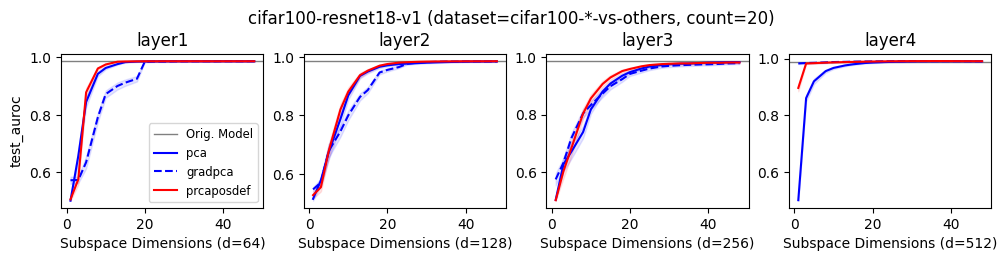

In [5]:
viz(
    dataset_name="cifar100-*-vs-others",
    arr_basis_names=[
        "pca",
        "gradpca",
        "prcaposdef"
    ]
)

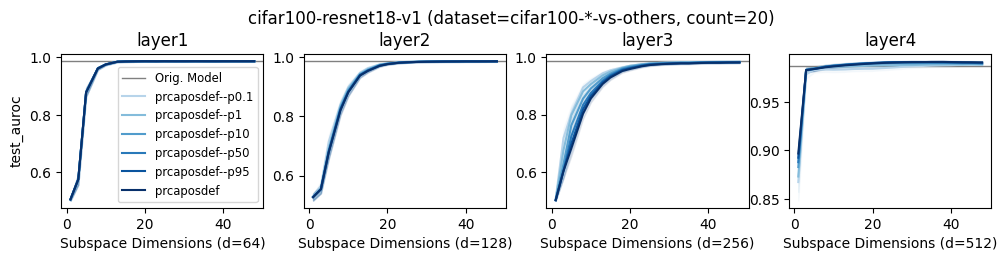

In [6]:
def ano():
        
    cmap = mpl.colormaps["Blues"]

    arr_basis_names = [
        "prcaposdef-with-weight-p0.1",
        "prcaposdef-with-weight-p1",
        "prcaposdef-with-weight-p10",
        "prcaposdef-with-weight-p50",
        "prcaposdef-with-weight-p95",
        "prcaposdef"
    ]

    scales = np.linspace(0.3, 1, len(arr_basis_names))

    ls = ["-"] * len(arr_basis_names)
    colors = list(map(lambda i: cmap(i), scales))

    
    dict_color_ls = dict(zip(arr_basis_names, list(zip(colors, ls))))
    
    viz(
        dataset_name="cifar100-*-vs-others", 
        arr_basis_names=arr_basis_names,
        dict_color_ls=dict_color_ls,
    )
ano()

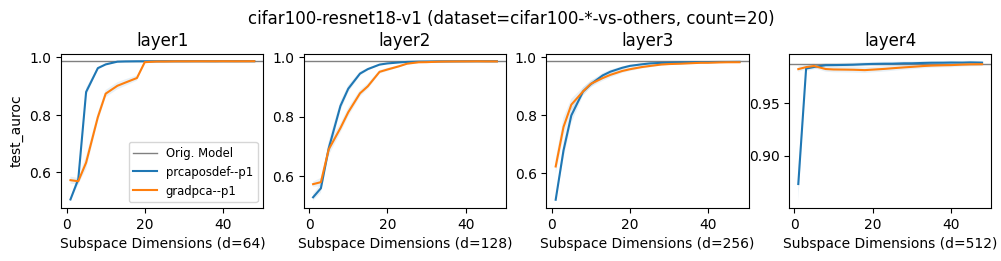

In [7]:
viz(
    dataset_name="cifar100-*-vs-others",
    arr_basis_names=[
        "prcaposdef-with-weight-p1",
        "gradpca-with-weight-p1",
    ],
)

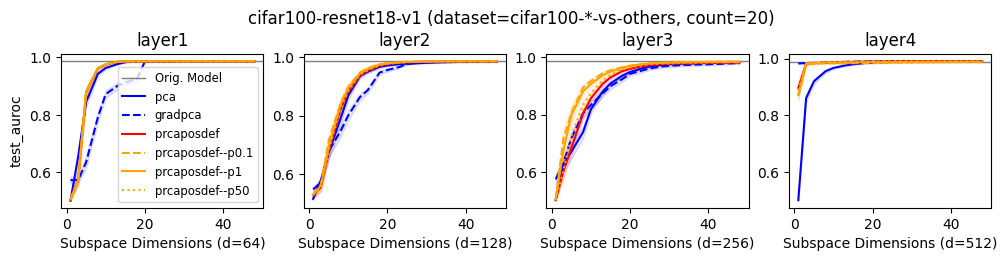

In [8]:
viz(
    dataset_name="cifar100-*-vs-others",
    arr_basis_names=[
        "pca",
        "gradpca",
        "prcaposdef",
        "prcaposdef-with-weight-p0.1",
        "prcaposdef-with-weight-p1",
        "prcaposdef-with-weight-p50",
    ],
    dict_color_ls={
        "pca":        ("blue", "-"),
        "gradpca":    ("blue", "--"),
        "prcaposdef": ("red",  "-"),
        "prcaposdef-with-weight-p1": ("orange",  "-"),
        "prcaposdef-with-weight-p0.1": ("orange",  "--"),
        "prcaposdef-with-weight-p50": ("orange",  ":"),
    }
)

# CelebA

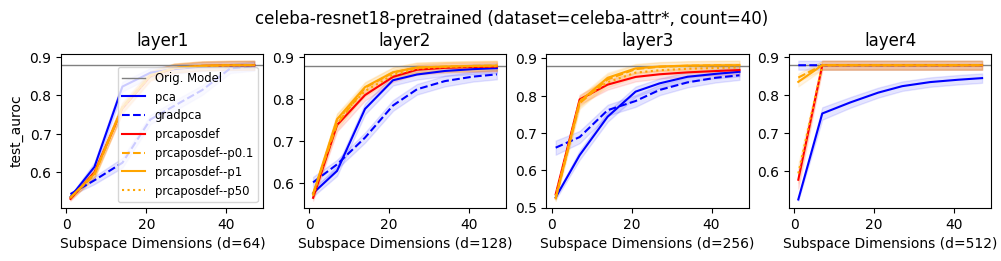

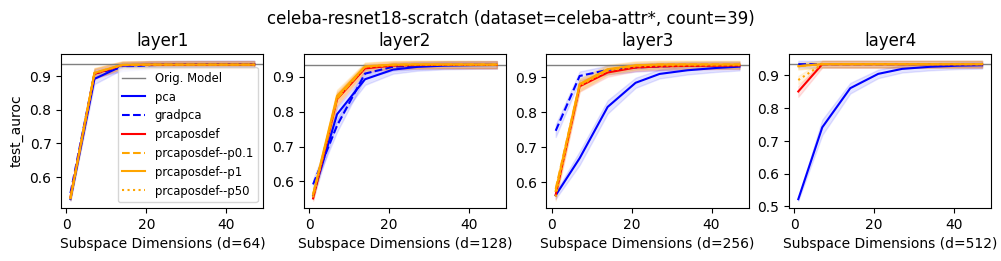

In [13]:
for model_name in [
    "celeba-resnet18-pretrained",
    "celeba-resnet18-scratch"
]:
    viz(
        model_name=model_name, 
        dataset_name="celeba-attr*", 
        arr_basis_names=[
            "pca",
            "gradpca",
            "prcaposdef",
            "prcaposdef-with-weight-p0.1",
            "prcaposdef-with-weight-p1",
            "prcaposdef-with-weight-p50",
        ],
        dict_color_ls={
            "pca":        ("blue", "-"),
            "gradpca":    ("blue", "--"),
            "prcaposdef": ("red",  "-"),
            "prcaposdef-with-weight-p1": ("orange",  "-"),
            "prcaposdef-with-weight-p0.1": ("orange",  "--"),
            "prcaposdef-with-weight-p50": ("orange",  ":"),
        }
    )

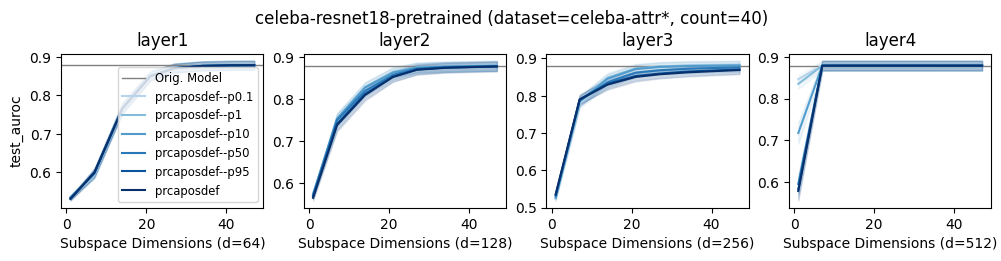

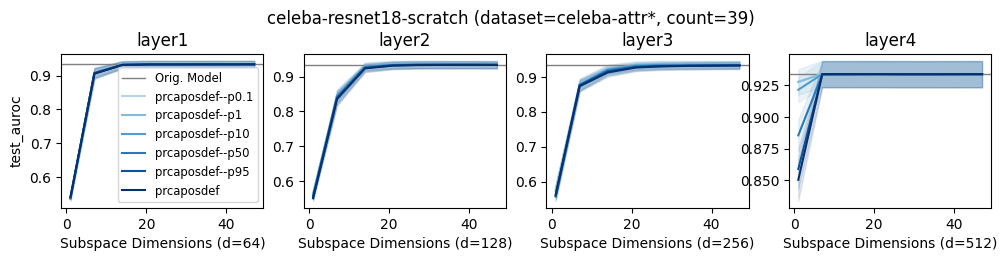

In [23]:
def ano():
        
    cmap = mpl.colormaps["Blues"]

    arr_basis_names = [
        "prcaposdef-with-weight-p0.1",
        "prcaposdef-with-weight-p1",
        "prcaposdef-with-weight-p10",
        "prcaposdef-with-weight-p50",
        "prcaposdef-with-weight-p95",
        "prcaposdef"
    ]

    scales = np.linspace(0.3, 1, len(arr_basis_names))

    ls = ["-"] * len(arr_basis_names)
    colors = list(map(lambda i: cmap(i), scales))

    
    dict_color_ls = dict(zip(arr_basis_names, list(zip(colors, ls))))
    for model_name in [
        "celeba-resnet18-pretrained",
        "celeba-resnet18-scratch"
    ]:
        
        viz(
            model_name=model_name, 
            dataset_name="celeba-attr*", 
            arr_basis_names=arr_basis_names,
            dict_color_ls=dict_color_ls,
        )
ano()

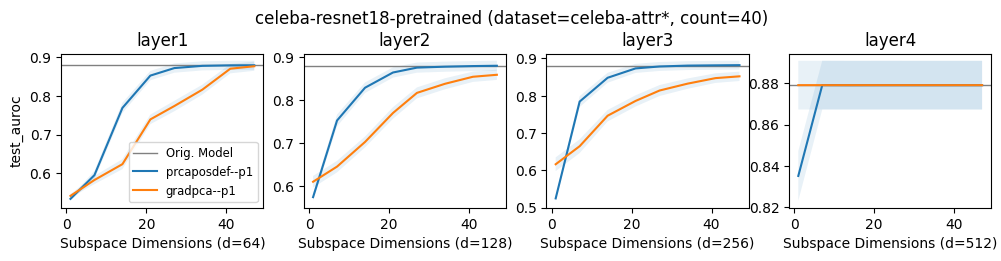

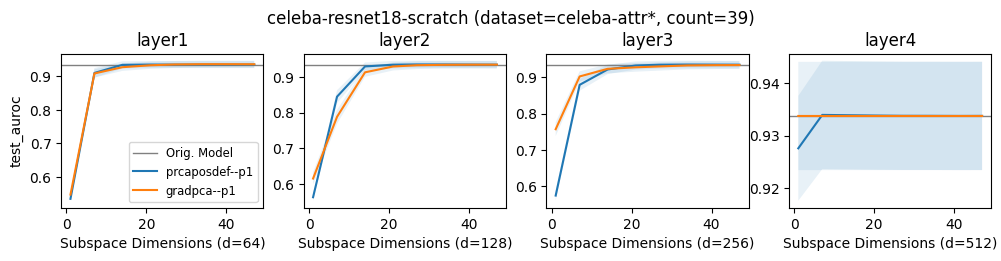

In [24]:
for model_name in [
    "celeba-resnet18-pretrained",
    "celeba-resnet18-scratch"
]:
    
    viz(
        model_name=model_name,
        dataset_name="celeba-attr*", 
        arr_basis_names=[
            "prcaposdef-with-weight-p1",
            "gradpca-with-weight-p1",
        ],
    )

In [12]:
print(f"finished at {datetime.now()}")

finished at 2025-03-20 06:45:19.386713
